In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#train_FD001.txt dosyasında başlık satırı yoktur
# 1. Sütun isimlerini belirleme.
index_columns = ['unit_number', 'time_in_cycles']
setting_columns = ['setting_1', 'setting_2', 'setting_3']
sensor_columns = [f'sensor_{i}' for i in range(1, 22)]
columns = index_columns + setting_columns + sensor_columns

In [4]:
# 2. train_FD001.txt verisini okuma
# (Dosyadaki boşlukları sep=r'\s+' ile yakalıyoruz)\s+
train_df = pd.read_csv(
    '../data/raw/train_FD001.txt',
    sep=r'\s+',
    header=None,
    names=columns
)

In [5]:
# İlk 5 satıra ve veri boyutuna göz atalım
print(f"Veri boyutu: {train_df.shape}")
train_df.head()

Veri boyutu: (20631, 26)


,unit_number,time_in_cycles,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [6]:
# 1. Toplam benzersiz motor sayısı
num_units = train_df['unit_number'].nunique()
print(f"Toplam motor sayısı: {num_units}")

Toplam motor sayısı: 100


In [8]:
# 2. Her motorun maksimum çalışma döngüsü (arıza anı)
max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max()

print("\nMotor Ömrü (Max Cycle) İstatistikleri:")
print(max_cycles.describe())


Motor Ömrü (Max Cycle) İstatistikleri:
count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: time_in_cycles, dtype: float64


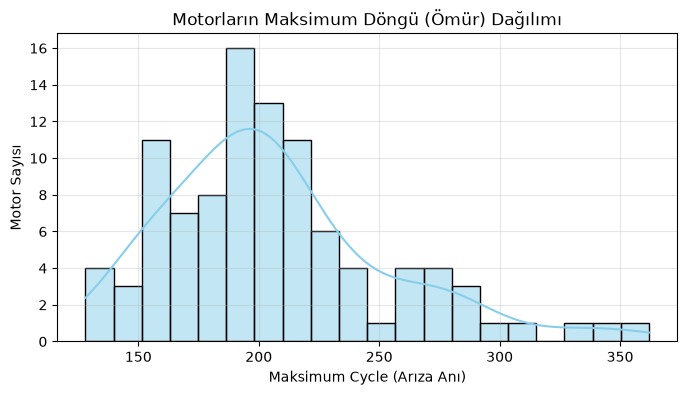

In [9]:
# 3. Motor ömürlerinin dağılım grafiği
plt.figure(figsize=(8, 4))
sns.histplot(max_cycles, kde=True, bins=20, color='skyblue')
plt.title('Motorların Maksimum Döngü (Ömür) Dağılımı')
plt.xlabel('Maksimum Cycle (Arıza Anı)')
plt.ylabel('Motor Sayısı')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
# Tüm sensörlerin standart sapmalarını (değişkenliklerini) hesaplayalım
sensor_std = train_df[sensor_columns].std()

In [11]:
# Değişkenliği (std) 0 olan veya 0'a çok yakın olan sensörleri filtreleyelim
constant_sensors = sensor_std[sensor_std < 0.01].index.tolist()

In [12]:
print("Sabit / Bilgi Taşımayan Sensörler:")
print(constant_sensors)

print("\nSensörlerin Standart Sapma Değerleri:")
print(sensor_std)

Sabit / Bilgi Taşımayan Sensörler:
['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']

Sensörlerin Standart Sapma Değerleri:
sensor_1     0.000000e+00
sensor_2     5.000533e-01
sensor_3     6.131150e+00
sensor_4     9.000605e+00
sensor_5     5.329200e-15
sensor_6     1.388985e-03
sensor_7     8.850923e-01
sensor_8     7.098548e-02
sensor_9     2.208288e+01
sensor_10    0.000000e+00
sensor_11    2.670874e-01
sensor_12    7.375534e-01
sensor_13    7.191892e-02
sensor_14    1.907618e+01
sensor_15    3.750504e-02
sensor_16    3.469531e-18
sensor_17    1.548763e+00
sensor_18    0.000000e+00
sensor_19    0.000000e+00
sensor_20    1.807464e-01
sensor_21    1.082509e-01
dtype: float64


In [13]:
# 1. Setting sütunlarının standart sapmalarına bakalım
print("Çalışma Ayarları (Settings) Standart Sapmaları:")
print(train_df[setting_columns].std())

Çalışma Ayarları (Settings) Standart Sapmaları:
setting_1    0.002187
setting_2    0.000293
setting_3    0.000000
dtype: float64


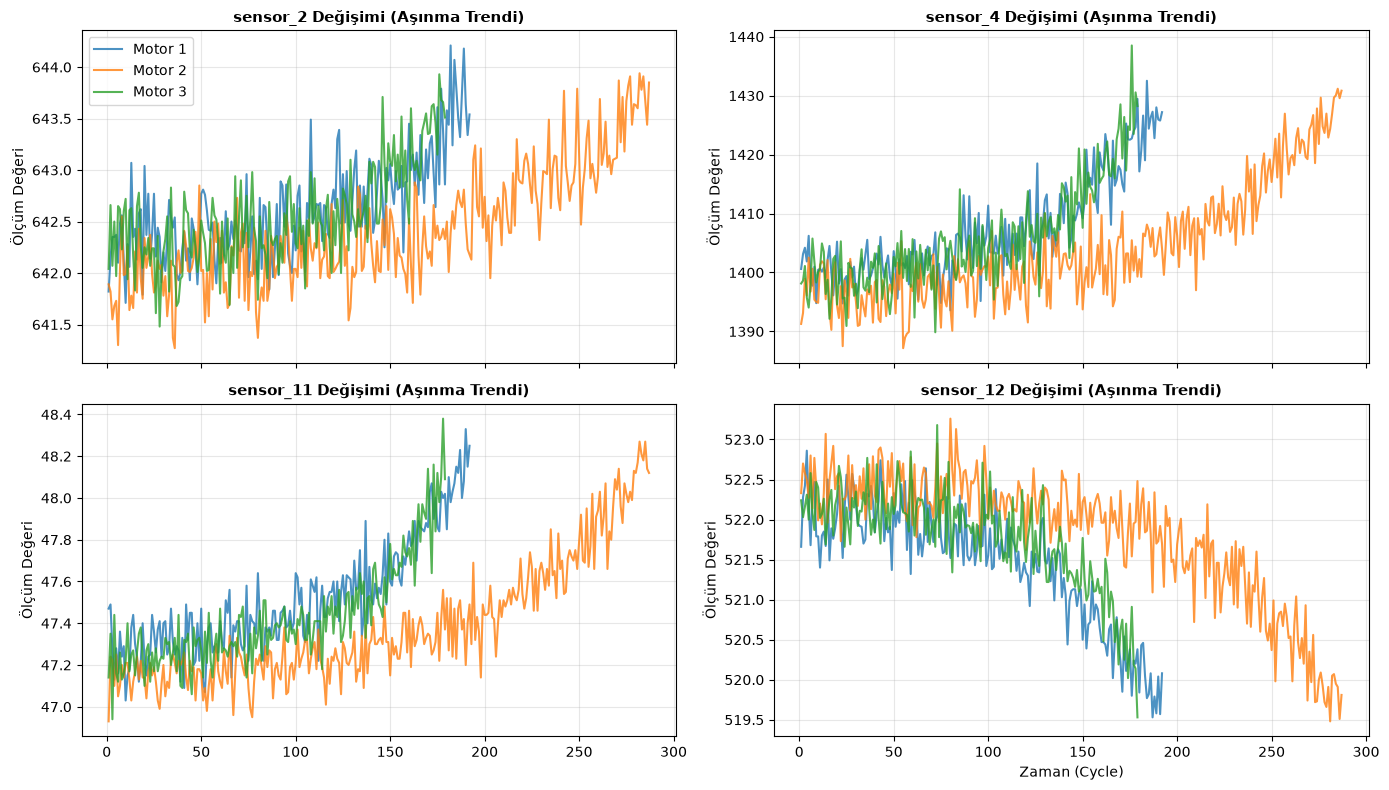

In [16]:
# 2. Değişim gösteren önemli bazı sensörleri (örn: sensor_2, sensor_4, sensor_11, sensor_12)
# ilk 3 motor (unit_number = 1, 2, 3) için zamana karşı çizdirelim
trend_sensors = ['sensor_2', 'sensor_4', 'sensor_11', 'sensor_12']

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

sample_units = [1, 2, 3]

for idx, sensor in enumerate(trend_sensors):
    ax = axes[idx]
    for unit in sample_units:
        unit_data = train_df[train_df['unit_number'] == unit]
        ax.plot(unit_data['time_in_cycles'], unit_data[sensor], label=f'Motor {unit}', alpha=0.8)
    ax.set_title(f'{sensor} Değişimi (Aşınma Trendi)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Ölçüm Değeri')
    ax.grid(True, alpha=0.3)
    if idx == 0:
        ax.legend()
   
    plt.xlabel('Zaman (Cycle)')
plt.tight_layout()
plt.show()

In [17]:
# 1. Her motorun maksimum cycle değerini ana tabloya eşleyelim
max_cycle_df = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycle_df.columns = ['unit_number', 'max_cycle']

In [18]:
# 2. train_df ile birleştirip ham RUL'u hesaplayalım
train_df = train_df.merge(max_cycle_df, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']

In [19]:
# 3. Literatür standardı olan 125 tavan değeriyle kırpılmış RUL (RUL_clipped) oluşturalım
MAX_RUL = 125
train_df['RUL_clipped'] = train_df['RUL'].clip(upper=MAX_RUL)

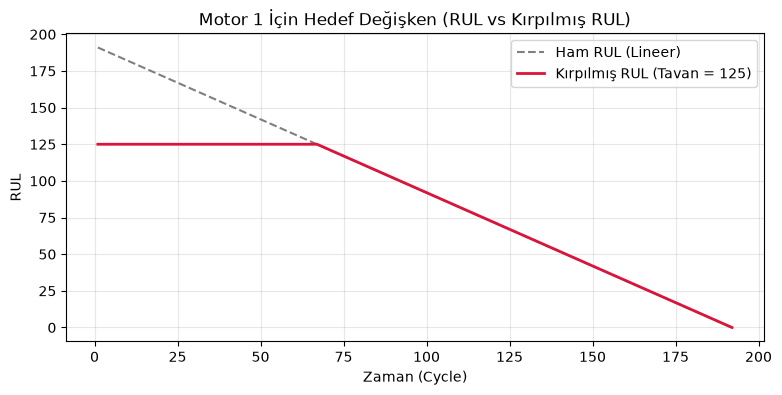

In [21]:
# 4. İlk motorun (unit_number = 1) RUL eğrisini görselleştirelim
unit_1 = train_df[train_df['unit_number'] == 1]

plt.figure(figsize=(9, 4))
plt.plot(unit_1['time_in_cycles'], unit_1['RUL'], label='Ham RUL (Lineer)', linestyle='--', color='gray')
plt.plot(unit_1['time_in_cycles'], unit_1['RUL_clipped'], label=f'Kırpılmış RUL (Tavan = {MAX_RUL})', color='crimson', linewidth=2)
plt.title('Motor 1 İçin Hedef Değişken (RUL vs Kırpılmış RUL)')
plt.xlabel('Zaman (Cycle)')
plt.ylabel('RUL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [22]:
# İlk birkaç satırı görelim
train_df[['unit_number', 'time_in_cycles', 'max_cycle', 'RUL', 'RUL_clipped']].head(10)

,unit_number,time_in_cycles,max_cycle,RUL,RUL_clipped
0,1,1,192,191,125
1,1,2,192,190,125
2,1,3,192,189,125
3,1,4,192,188,125
4,1,5,192,187,125
5,1,6,192,186,125
6,1,7,192,185,125
7,1,8,192,184,125
8,1,9,192,183,125
9,1,10,192,182,125
